In [76]:
# Librerías 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
# Cargamos la base sin considerar las primeras dos filas

df = pd.read_csv("Analisis GAC Full7agosto 2026(Leads Reales).csv",skiprows=2)


# Mostramos las primeras filas

df.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN,NaN


In [78]:
# Eliminamos las columnas "Unnamed"

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]


# Quitamos espacios al inicio o al final de los nombres

df.columns = df.columns.str.strip()

df.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%


In [79]:
# Rellenamos los valores nulos con el año anterior

df["Año"] = df["Año"].ffill()


# Convertimos la columna Año a tipo numérico

df["Año"] = pd.to_numeric(df["Año"], errors="coerce")

In [80]:
# Quitamos espacios de los nombres de los meses

df["Mes"] = df["Mes"].str.strip()


# Creamos un diccionario con el número correspondiente a cada mes

meses = {"Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
         "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
         "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12}

In [81]:
# Reemplazamos los nombres por sus números

df["Mes"] = df["Mes"].map(meses)


# Eliminamos las filas inferiores que no corresponden a meses

df = df.dropna(subset=["Mes"])


# Convertimos Mes a tipo numérico entero

df["Mes"] = df["Mes"].astype(int)

In [82]:
# Seleccionamos las columnas de tipos de leads

columnas_leads = ["Total", "Ilocalizable", "No Contesta",
                  "D. Incorrectos","Duplicados", "Efectivos",
                  "Abiertos", "Ventas"]

In [83]:
# Quitamos las comas y convertimos las columnas a numérico

for columna in columnas_leads:
    df[columna] = df[columna].astype(str).str.replace(",", "", regex=False)
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

In [84]:
# Quitamos el signo % de las columnas porcentuales

columnas_porcentaje = ["Conversion","Efectividad de Leads"]

for columna in columnas_porcentaje:
    df[columna] = df[columna].astype(str).str.replace("%", "", regex=False)
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

In [85]:
df.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024.0,2,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,3.1,72.0
2,2024.0,3,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,5.5,72.0
3,2024.0,4,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,2.8,69.0
4,2024.0,5,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,4.7,65.0


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   29 non-null     float64
 1   Mes                   29 non-null     int64  
 2   Total                 28 non-null     float64
 3   Ilocalizable          28 non-null     float64
 4   No Contesta           28 non-null     float64
 5   D. Incorrectos        28 non-null     float64
 6   Duplicados            28 non-null     float64
 7   Efectivos             28 non-null     float64
 8   Abiertos              28 non-null     float64
 9   Ventas                28 non-null     float64
 10  Conversion            28 non-null     float64
 11  Efectividad de Leads  28 non-null     float64
dtypes: float64(11), int64(1)
memory usage: 2.8 KB


In [87]:
df.isnull().sum()

Año                     0
Mes                     0
Total                   1
Ilocalizable            1
No Contesta             1
D. Incorrectos          1
Duplicados              1
Efectivos               1
Abiertos                1
Ventas                  1
Conversion              1
Efectividad de Leads    1
dtype: int64

In [88]:
# Matriz de correlación

# Columnas que se utilizarán para analizar la correlación

variables_leads = ["Total", "Ilocalizable", "No Contesta",
                   "D. Incorrectos", "Duplicados", "Efectivos",
                   "Abiertos", "Ventas", "Conversion", "Efectividad de Leads"]

In [89]:
# Correlaciones

Corr_Factors = df[variables_leads].corr()

Corr_Factors

,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
Total,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.534564,-0.133595,-0.653776
Ilocalizable,0.588110,1.000000,0.443577,0.293649,-0.162391,0.245740,-0.047827,-0.106959,-0.413785,-0.645820
No Contesta,0.644815,0.443577,1.000000,-0.040028,0.012199,0.383725,0.013522,0.219976,-0.088043,-0.611360
D. Incorrectos,0.453006,0.293649,-0.040028,1.000000,0.287165,0.468292,0.382420,0.143903,-0.247300,-0.177488
Duplicados,0.260949,-0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.451099,0.085728,0.139829
Efectivos,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,-0.137212,-0.115353
Abiertos,0.528382,-0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.752551,0.445734,-0.281941
Ventas,0.534564,-0.106959,0.219976,0.143903,0.451099,0.654887,0.752551,1.000000,0.626595,-0.115155
Conversion,-0.133595,-0.413785,-0.088043,-0.247300,0.085728,-0.137212,0.445734,0.626595,1.000000,0.021724
Efectividad de Leads,-0.653776,-0.645820,-0.611360,-0.177488,0.139829,-0.115353,-0.281941,-0.115155,0.021724,1.000000


In [90]:
# Valor absoluto de las correlaciones

Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
Total,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.534564,0.133595,0.653776
Ilocalizable,0.588110,1.000000,0.443577,0.293649,0.162391,0.245740,0.047827,0.106959,0.413785,0.645820
No Contesta,0.644815,0.443577,1.000000,0.040028,0.012199,0.383725,0.013522,0.219976,0.088043,0.611360
D. Incorrectos,0.453006,0.293649,0.040028,1.000000,0.287165,0.468292,0.382420,0.143903,0.247300,0.177488
Duplicados,0.260949,0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.451099,0.085728,0.139829
Efectivos,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,0.137212,0.115353
Abiertos,0.528382,0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.752551,0.445734,0.281941
Ventas,0.534564,0.106959,0.219976,0.143903,0.451099,0.654887,0.752551,1.000000,0.626595,0.115155
Conversion,0.133595,0.413785,0.088043,0.247300,0.085728,0.137212,0.445734,0.626595,1.000000,0.021724
Efectividad de Leads,0.653776,0.645820,0.611360,0.177488,0.139829,0.115353,0.281941,0.115155,0.021724,1.000000


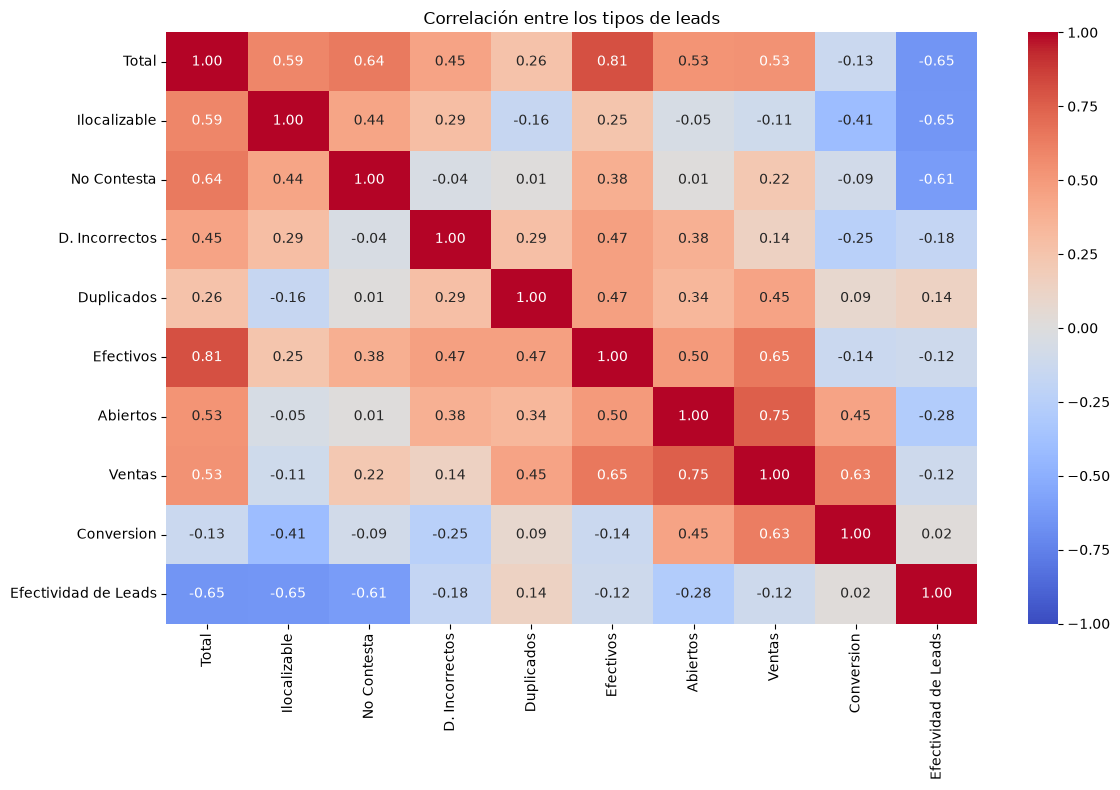

In [91]:
# Mapa de calor

plt.figure(figsize=(12, 8))
Heat_Map = sns.heatmap(Corr_Factors, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlación entre los tipos de leads")
plt.tight_layout()
plt.show()

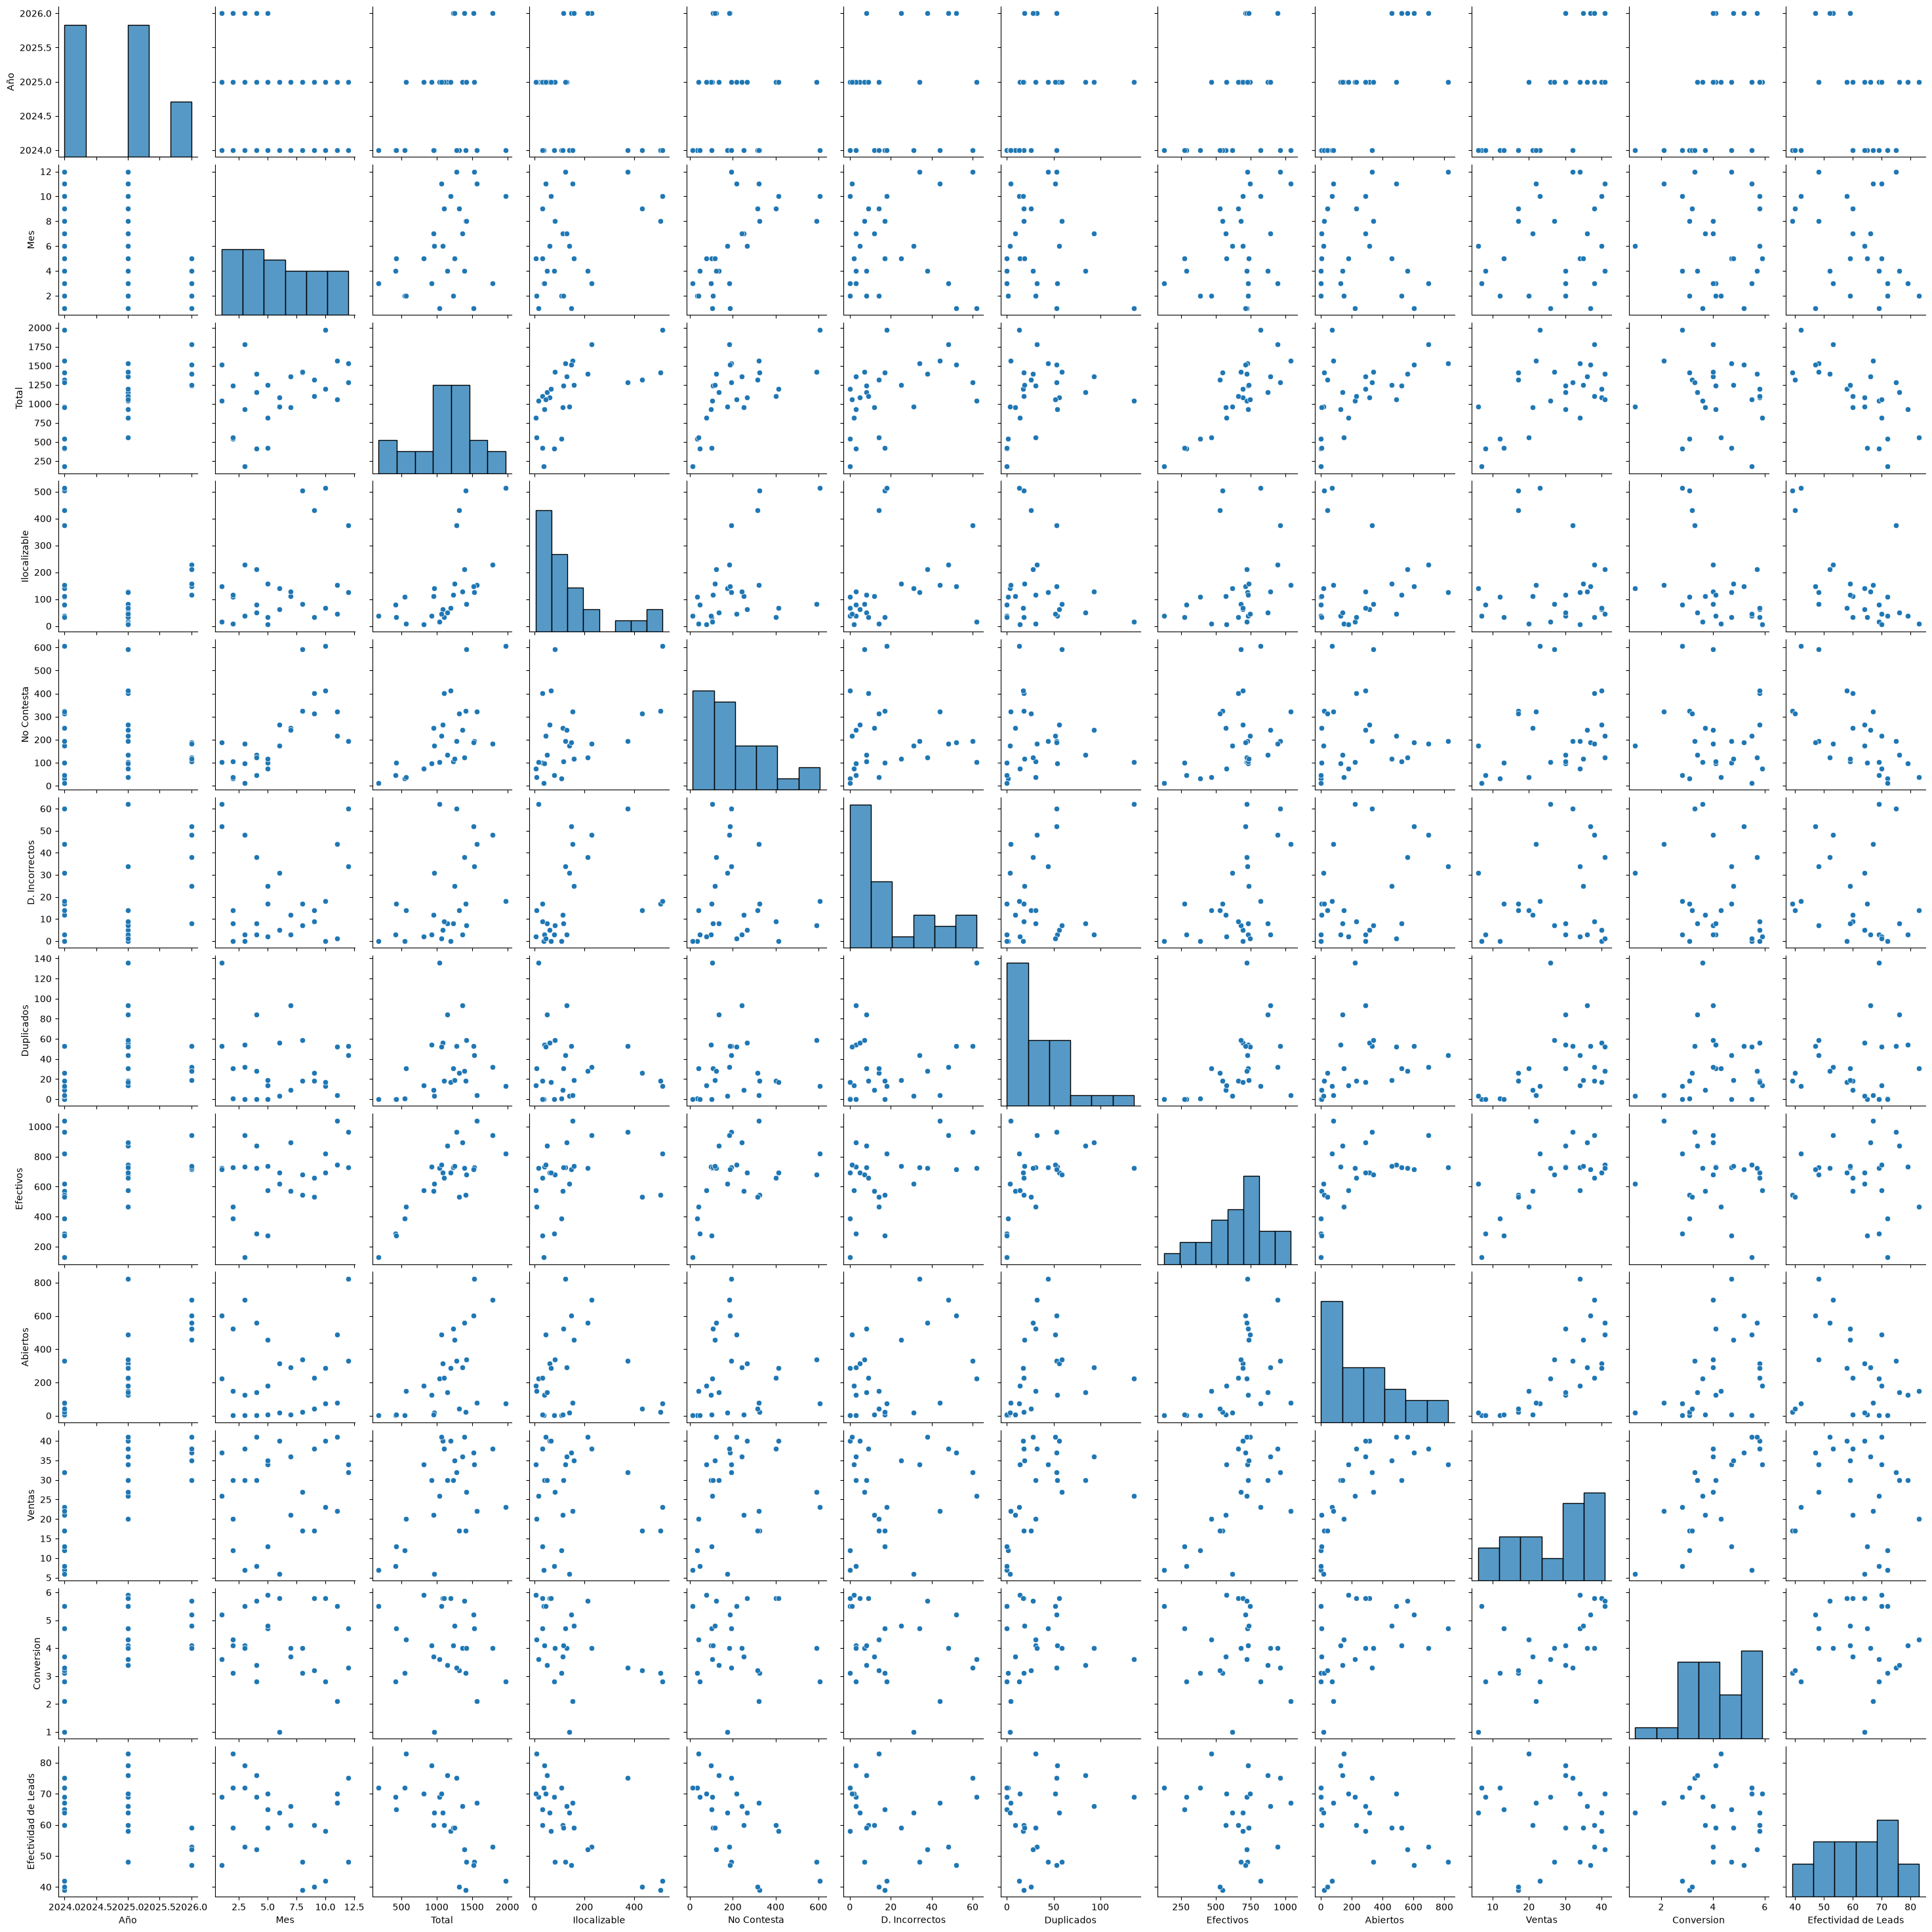

In [92]:
# Graficamos todas las dispersiones entre las variables

sns.pairplot(df)
plt.show()

In [93]:
# Eliminamos la fila que no tiene información en Total

df = df.dropna(subset=["Total"])


# Reiniciamos el índice

df = df.reset_index(drop=True)

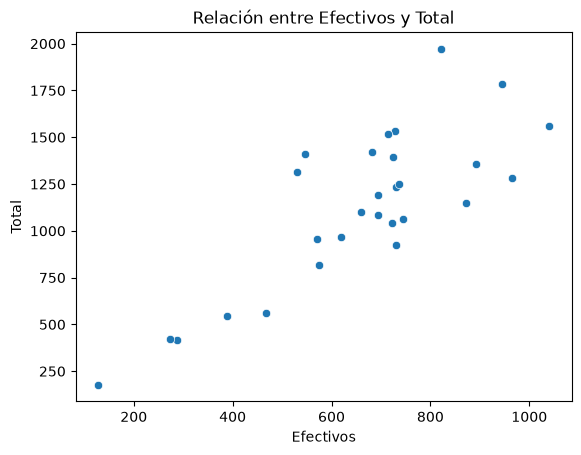

In [94]:
# Gráfica de dispersión entre Total y Efectivos

sns.scatterplot(x="Efectivos", y="Total", data=df)
plt.title("Relación entre Efectivos y Total")
plt.xlabel("Efectivos")
plt.ylabel("Total")
plt.show()

In [95]:
# Variable independiente y dependiente

Vars_Indep = df[["Efectivos"]]
Var_Dep = df["Total"]

In [96]:
# Modelo de regresión lineal

from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [97]:
# Ajustamos el modelo

model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.62]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Efectivos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,55.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [98]:
# Intercepto

model.intercept_

np.float64(55.600624186514096)

In [99]:
# Coeficiente de la variable independiente: Efectivos

model.coef_

array([1.6167054])

**Modelo matemático: Total = 1.6167054(Efectivos) + 55.600624186514096**


----

In [100]:
# Coeficiente de determinación

coef_Deter = model.score(X=Vars_Indep, y=Var_Dep)

coef_Deter

0.6593449223982559

In [101]:
# Coeficiente de correlación

coef_Correl = df["Efectivos"].corr(df["Total"])

coef_Correl

np.float64(0.8120005679790229)

In [102]:
# Predicciones del modelo

Predicciones = model.predict(X=Vars_Indep)

Predicciones

array([ 684.49902288,  262.53891476,  521.21177797,  498.57790244,
       1057.95796914,  977.12269939,  938.3217699 ,  912.45448358,
       1384.53245895, 1736.97423508, 1615.72133044, 1224.47862483,
        812.21874909, 1237.41226799, 1465.3677287 ,  983.58952097,
       1177.59416838, 1499.318542  , 1156.57699824, 1122.62618494,
       1179.21087377, 1258.42943813, 1234.1788572 , 1209.92827628,
       1235.7955626 , 1581.77051715, 1226.09533023, 1245.49579497])

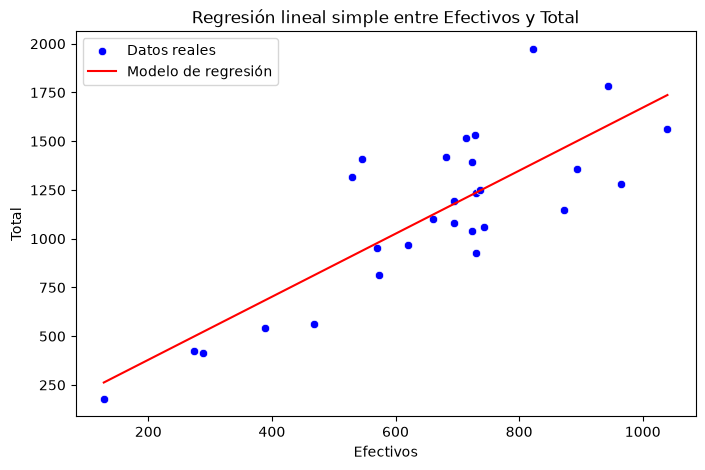

In [103]:
# Gráfica del modelo de regresión lineal

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Efectivos", y="Total", data=df, color="blue", label="Datos reales")

sns.lineplot(x=df["Efectivos"], y=Predicciones, color="red", label="Modelo de regresión")

plt.title("Regresión lineal simple entre Efectivos y Total")
plt.xlabel("Efectivos")
plt.ylabel("Total")
plt.legend()
plt.show()